<a href="https://colab.research.google.com/github/MarkKryvoshein/MachineLearning/blob/main/%D0%9A%D0%BB%D0%B0%D1%81%D0%B8%D1%84%D1%96%D0%BA%D0%B0%D1%86%D1%96%D1%8F_%D0%B7%D0%BE%D0%B1%D1%80%D1%80%D0%B0%D0%B6%D0%B5%D0%BD%D1%8C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import cv2
from PIL import Image

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [3]:
X_train = X_train / 255.0
X_test = X_test / 255.0

print(X_train)

[[[[0.23137255 0.24313725 0.24705882]
   [0.16862745 0.18039216 0.17647059]
   [0.19607843 0.18823529 0.16862745]
   ...
   [0.61960784 0.51764706 0.42352941]
   [0.59607843 0.49019608 0.4       ]
   [0.58039216 0.48627451 0.40392157]]

  [[0.0627451  0.07843137 0.07843137]
   [0.         0.         0.        ]
   [0.07058824 0.03137255 0.        ]
   ...
   [0.48235294 0.34509804 0.21568627]
   [0.46666667 0.3254902  0.19607843]
   [0.47843137 0.34117647 0.22352941]]

  [[0.09803922 0.09411765 0.08235294]
   [0.0627451  0.02745098 0.        ]
   [0.19215686 0.10588235 0.03137255]
   ...
   [0.4627451  0.32941176 0.19607843]
   [0.47058824 0.32941176 0.19607843]
   [0.42745098 0.28627451 0.16470588]]

  ...

  [[0.81568627 0.66666667 0.37647059]
   [0.78823529 0.6        0.13333333]
   [0.77647059 0.63137255 0.10196078]
   ...
   [0.62745098 0.52156863 0.2745098 ]
   [0.21960784 0.12156863 0.02745098]
   [0.20784314 0.13333333 0.07843137]]

  [[0.70588235 0.54509804 0.37647059]
   [0.6

In [4]:
class_name = ['літак', 'автомобіль', 'птах', 'кіт', 'олень', 'собака', 'жаба', 'кінь', 'корабель', 'вантажівка']

model = models.Sequential([layers.Conv2D(32, (3,3), activation="relu", input_shape=(32, 32, 3)),
                           layers.MaxPooling2D((2, 2)),

                           layers.Conv2D(64, (3,3), activation="relu"),
                           layers.MaxPooling2D((2, 2)),

                           layers.Conv2D(64, (3,3), activation="relu"),

                           layers.Flatten(),
                           layers.Dense(64, activation="relu"),
                           layers.Dense(10, activation="softmax")

                           ])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10


KeyboardInterrupt: 

In [5]:
class_name = ['літак', 'автомобіль', 'птах', 'кіт', 'олень', 'собака', 'жаба', 'кінь', 'корабель', 'вантажівка']

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),  # перший згортковий шар
    # 32 фільтри (або ядра згортки) розміром 3x3
    # relu (Rectified Linear Unit) — нелінійна функція активації: f(x) = max(0, x)
    # input_shape=(32, 32, 3) — 32x32 пікселі, 3 кольорові канали (RGB)
    layers.MaxPooling2D((2,2)),  # 32x32 -> 16x16  # підвибірка (pooling), зменшення розміру у 2 рази
    layers.Conv2D(64, (3, 3), activation='relu'),  # другий згортковий шар
    layers.MaxPooling2D((2,2)),  # 16x16 -> 8x8  # ще одна підвибірка
    layers.Conv2D(64, (3, 3), activation='relu'),  # третій згортковий шар
    layers.Flatten(),  # перетворення вектора ознак
    layers.Dense(64, activation='relu'),  # прихований повнозв’язний шар
    # Вихідний шар з 10 нейронами (по одному на кожен клас)
    # Softmax — функція, що перетворює числа у ймовірності (сумуються до 1.0)
    layers.Dense(10, activation='softmax')  # вихідний шар: 10 класів
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.4570 - loss: 1.5010 - val_accuracy: 0.5490 - val_loss: 1.2577
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5921 - loss: 1.1523 - val_accuracy: 0.5756 - val_loss: 1.2012
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6472 - loss: 1.0094 - val_accuracy: 0.6405 - val_loss: 1.0202
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6764 - loss: 0.9259 - val_accuracy: 0.6692 - val_loss: 0.9730
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7027 - loss: 0.8522 - val_accuracy: 0.6822 - val_loss: 0.9130
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7255 - loss: 0.7901 - val_accuracy: 0.6773 - val_loss: 0.9415
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7396 - loss: 0.7409 - val_accuracy: 0.6970 - val_loss: 0.8777
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7562 - loss: 0.6937 -

In [6]:
loss, acc = model.evaluate(X_test, y_test)

print(f"Loss:{loss}, accuracy:{acc:.2f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7088 - loss: 0.8801
Loss:0.8800822496414185, accuracy:0.71


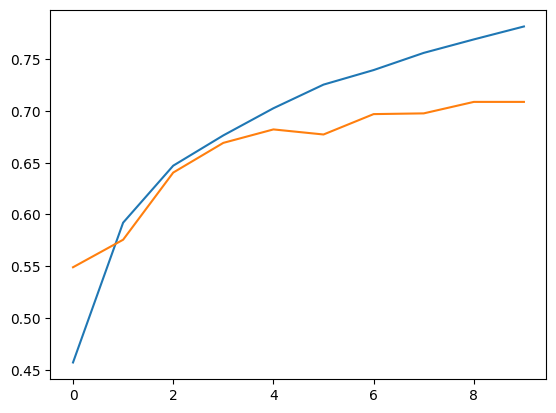

In [7]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

In [8]:
def load_and_prepare(img):
  image = Image.open(img).convert('RGB')
  image = image.resize((32, 32))

  image_array = np.array(image) / 255.0
  image_array = np.expand_dims(image_array, axis=0)

  return image_array

In [9]:
import os
custom_image_path = "8624553.png"
if os.path.exists(custom_image_path):
    try:
        prepared_image = load_and_prepare(custom_image_path)
        prediction = model.predict(prepared_image)

        predicted_class = np.argmax(prediction)
        confidence = np.max(prediction)

        print(f"pred {predicted_class} {class_name[predicted_class]}, confidence: {confidence * 100:.2f}%")

    except Exception as e:
        print("Error:", e)

In [18]:
from google.colab import files
uploaded = files.upload()

Saving 1.jpg to 1 (2).jpg


Pred: 8 (корабель) - 83.31%


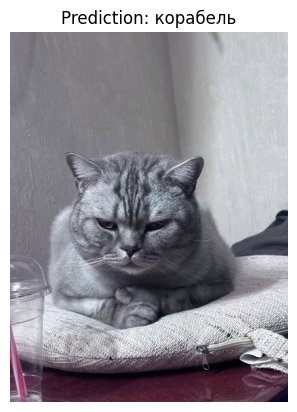

In [19]:
for f in uploaded.keys():
    img = f
    prepared_img = load_and_prepare(img)

    prediction = model.predict(prepared_img, verbose=0)

    predicted_class = np.argmax(prediction[0])
    confidence = np.max(prediction[0])

    print(f"Pred: {predicted_class} ({class_name[predicted_class]}) - {confidence*100:.2f}%")

    img = Image.open(f)

    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prediction: {class_name[predicted_class]}")
    plt.show()

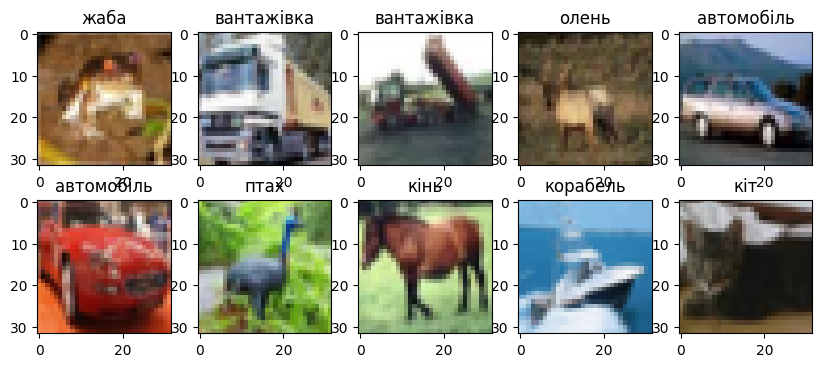

In [35]:

plt.figure(figsize=(10,4))
for i in range(10):
  plt.subplot(2,5, i+1)
  plt.imshow(X_train[i])
  plt.title(class_name[y_train[i][0]])
plt.show()

9
